<a href="https://colab.research.google.com/github/APES-M-JeissonS-JuanB/Sesion_3_Pruebas_de_hipotesis/blob/main/Sesi%C3%B3n_2_%C2%A0An%C3%A1lisis_Descriptivo_Multivariado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sesión 2: Análisis Descriptivo Multivariado

Antes de continuar con el análisis descriptivo multivariado, miremos algunos análisis y gráficas complementarias, univariadas. A continuación, tomaremos como ejemplo el dataset de la libreria seaborn llamada "tips" que contiene datos sobre propinas en restaurantes, y tiene las siguientes variables:

1. ***total_bill***: El total de la cuenta en el restaurante, incluyendo el costo de la comida y cualquier cargo adicional.

2. ***tip***: La cantidad de propina dejada por el cliente.

3. ***sex***: El género del camarero/a que atendió la mesa (Femenino o Masculino).

4. ***smoker***: Si la persona que hizo la reserva es fumadora o no (Sí o No).

5. ***day***: El día en que se realizó la comida (Jueves, Viernes, Sábado o Domingo).

6. ***time***: Si la comida fue en la hora del almuerzo o la cena (Almuerzo o Cena).

7. ***size***: El tamaño de la mesa (número de comensales).

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import trim_mean
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar el conjunto de tips
tips_data = sns.load_dataset("tips")
tips_data.sample(10)

,total_bill,tip,sex,smoker,day,time,size
64,17.59,2.64,Male,No,Sat,Dinner,3
110,14.00,3.00,Male,No,Sat,Dinner,2
119,24.08,2.92,Female,No,Thur,Lunch,4
131,20.27,2.83,Female,No,Thur,Lunch,2
130,19.08,1.50,Male,No,Thur,Lunch,2
202,13.00,2.00,Female,Yes,Thur,Lunch,2
115,17.31,3.50,Female,No,Sun,Dinner,2
84,15.98,2.03,Male,No,Thur,Lunch,2
124,12.48,2.52,Female,No,Thur,Lunch,2
133,12.26,2.00,Female,No,Thur,Lunch,2


Para obtener unas medidas descriptivas univariadas, se puede usar "describe" con la libreria "Pandas"

In [ ]:
tips_data.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [ ]:
tips_data.describe(include="all")

,total_bill,tip,sex,smoker,day,time,size
count,244.000000,244.000000,244,244,244,244,244.000000
unique,NaN,NaN,2,2,4,2,NaN
top,NaN,NaN,Male,No,Sat,Dinner,NaN
freq,NaN,NaN,157,151,87,176,NaN
mean,19.785943,2.998279,NaN,NaN,NaN,NaN,2.569672
std,8.902412,1.383638,NaN,NaN,NaN,NaN,0.951100
min,3.070000,1.000000,NaN,NaN,NaN,NaN,1.000000
25%,13.347500,2.000000,NaN,NaN,NaN,NaN,2.000000
50%,17.795000,2.900000,NaN,NaN,NaN,NaN,2.000000
75%,24.127500,3.562500,NaN,NaN,NaN,NaN,3.000000


Para las variables categóricas, se puede crear una tabla de frecuencias y su respectiva gráfica de barras que permita visualizar estos datos:

In [ ]:
# Frecuencias por variable
categoricas = ["sex","smoker","day","time","size"]
for variable in categoricas:
  print(tips_data.groupby(variable).size())
  print("--")


sex
Male      157
Female     87
dtype: int64
--
smoker
Yes     93
No     151
dtype: int64
--
day
Thur    62
Fri     19
Sat     87
Sun     76
dtype: int64
--
time
Lunch      68
Dinner    176
dtype: int64
--
size
1      4
2    156
3     38
4     37
5      5
6      4
dtype: int64
--


In [ ]:
import plotly.express as px
for variables in categoricas:
  fig = px.bar(tips_data.groupby(variables).size(), title="Frecuencias de la variable "+variables)
  fig.show()

### Otras medidas de tendencia central

La media robusta, eliminar valores de fracciones extremas: media truncada (trimmed mean).


Ejemplo: Descartamos el 10% de los valores extremos en las variables numéricas del ejemplo anterior:

In [ ]:
numericas=['total_bill',"tip"]
for variable in numericas:
  print(f"La media truncada en la variable "+variable+" es:",trim_mean(tips_data[variable], 0.10))

La media truncada en la variable total_bill es: 18.733214285714286
La media truncada en la variable tip es: 2.8427040816326534


Nos podemos preguntar que tipo de sesgo tienen nuestras variables numéricas:


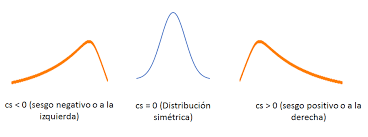

In [ ]:
for variable in numericas:
  fig = px.histogram(tips_data, x=variable)
  fig.show()

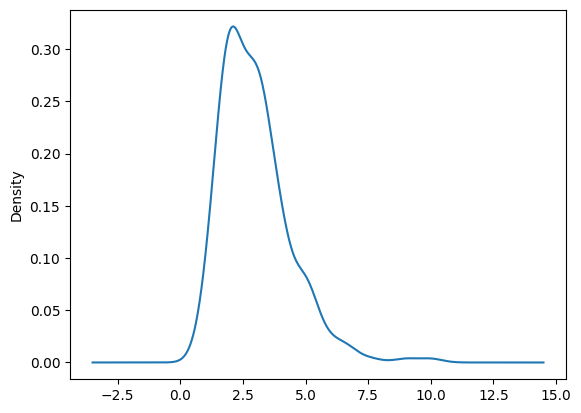

In [ ]:
#Densidad variable tip
ax = tips_data['tip'].plot.kde()

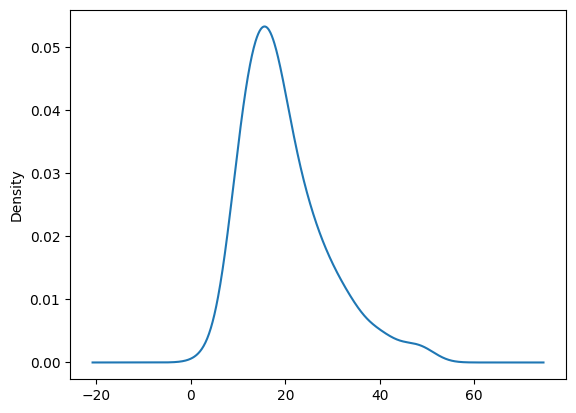

In [ ]:
#Densidad variable total_bill
ax = tips_data['total_bill'].plot.kde()

### Diagramas de cajas

Los diagramas de caja, también conocidos como box plots, son una herramienta de visualización estadística que muestra la distribución de un conjunto de datos y resalta características importantes como la mediana, cuartiles y posibles valores atípicos. Estos gráficos son especialmente útiles para analizar la dispersión y la forma de la distribución de los datos.

Un diagrama de caja consta de los siguientes elementos:

1. ***Caja (Box)***: La caja representa el rango intercuartílico (IQR), que es el rango que abarca desde el primer cuartil (Q1) hasta el tercer cuartil (Q3). La altura de la caja muestra la dispersión intercuartílica de los datos.

2. ***Mediana (Mediana)***: La línea dentro de la caja representa la mediana, que es el valor que divide el conjunto de datos en dos partes iguales, con el 50% de los datos por encima y el 50% por debajo.

3. ***Bigotes (Whiskers)***: Los bigotes se extienden desde la caja hasta los valores mínimos y máximos que no se consideran valores atípicos. Los valores atípicos se representan como puntos individuales más allá de los bigotes.

4. ***Valores atípicos (Outliers)***: Los valores que están significativamente por encima o por debajo de la mayoría de los datos se consideran valores atípicos y se representan como puntos individuales.

Los diagramas de caja te permiten tener una idea rápida de la distribución de los datos, identificar si hay valores atípicos y comparar distribuciones entre diferentes categorías o grupos. Son especialmente útiles cuando se trabaja con conjuntos de datos grandes o cuando se desea analizar la variabilidad y la forma de la distribución sin tener que calcular estadísticas detalladas.

In [ ]:
for variables in numericas:
  fig = px.box(tips_data,  y=variables, points="all")
  fig.show()

De esta misma forma, se pueden establecer las distribuciones de las variables segmentadas por variable categoricas, por ejemplo:

In [ ]:
fig = px.histogram(tips_data, x="tip", color="sex")
fig.show()

In [ ]:
fig = px.box(tips_data, x="sex", y="tip", points="all")
fig.show()

## 2.1 Covarianza y Correlación

En el vasto campo del análisis estadístico, el estudio de cómo las variables se relacionan entre sí es fundamental para comprender patrones, tendencias y posibles conexiones en los datos. La covarianza y la correlación son dos conceptos clave que nos permiten cuantificar y evaluar la naturaleza de estas relaciones. En esta sección, exploraremos en detalle estos dos conceptos esenciales y comprenderemos cómo nos brindan información valiosa sobre la interacción entre variables.

### 2.1.1 Covarianza

La covarianza es una medida que nos indica cómo dos variables numéricas cambian en conjunto. Si dos variables tienden a aumentar simultáneamente, su covarianza será positiva, mientras que si una tiende a aumentar mientras que la otra disminuye, la covarianza será negativa. Por otro lado, si las variables no parecen tener un patrón claro de cambio conjunto, la covarianza será cercana a cero. A través de ejemplos, exploraremos cómo interpretar estos valores de covarianza y entender las relaciones subyacentes entre las variables.

$COV(X,Y)=\frac{\sum_{i=1}^n(x_i-\bar{x})(y_i-\bar{y})}{n}$



In [ ]:
# Calcular la covarianza entre tip y total_bill
covariance = np.cov(tips_data['total_bill'], tips_data['tip'])
covariance

array([[79.25293861,  8.32350163],
       [ 8.32350163,  1.91445464]])

La interpretación de los valores de covarianza depende de si los valores son positivos, negativos o cercanos a cero. La covarianza mide la relación lineal entre dos variables, pero no proporciona una medida estandarizada de la intensidad de la relación. Aquí hay algunas interpretaciones comunes:

1. ***Covarianza positiva***: Si el valor de la covarianza es positivo, significa que cuando una variable tiende a aumentar, la otra variable también tiende a aumentar. Esto sugiere una relación positiva entre las variables, lo que significa que tienden a moverse en la misma dirección.

2. ***Covarianza negativa***: Si el valor de la covarianza es negativo, significa que cuando una variable tiende a aumentar, la otra variable tiende a disminuir. Esto sugiere una relación negativa entre las variables, lo que significa que tienden a moverse en direcciones opuestas.

3. ***Covarianza cercana a cero***: Si el valor de la covarianza es cercano a cero, no hay una relación lineal clara entre las variables. Esto puede indicar que no hay una tendencia evidente de aumento o disminución conjunta entre las variables.







### 2.1.2 Correlación

La correlación es una medida estadística fundamental que evalúa la fuerza y la dirección de la relación lineal entre dos variables. Cuando nos enfrentamos a conjuntos de datos en los que deseamos comprender si existe una relación directa o inversa entre las variables, la correlación se convierte en una herramienta esencial. No solo nos permite cuantificar la intensidad de la asociación lineal, sino que también nos ayuda a identificar patrones y tendencias en los datos.

El coeficiente de correlación más comúnmente utilizado es el coeficiente de correlación de Pearson.

La fórmula del coeficiente de correlación de Pearson entre dos conjuntos de datos x e y es la siguiente:

$$r = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^n (x_i - \bar{x})^2 \sum_{i=1}^{n} (y_i - \bar{y})^2}}$$

Donde:

*    n es el número de observaciones en los conjuntos de datos.
*    $x_i$ y $y_i$ son los valores individuales en los conjuntos de datos x e y.
*    $\bar{x}$ y $\bar{y}$ son las medias de los conjuntos de datos x e y, respectivamente.

El valor del coeficiente de correlación r estará en el rango de -1 a 1:


*   $r=1$ indica una correlación positiva perfecta.
*   $r=-1$ indica una correlación negativa perfecta.
*   $r=0$ indica ausencia de correlación lineal.

Ejemplo:

In [ ]:
# Calcular la correlación entre total_bill y tip
correlation_matrix = np.corrcoef(tips_data['total_bill'], tips_data['tip'])
correlation_matrix

array([[1.        , 0.67573411],
       [0.67573411, 1.        ]])

Otras medidas para la correlación entre variables son:

1.   ***Coeficiente de Correlación de Spearman***

2.   ***Coeficiente de Correlación de Kendall***

3.   ***Coeficiente de Correlación Puntual Biserial***

4.   ***Coeficiente de Determinación (R-cuadrado)***

5.   ***Coeficiente de Correlación de Pearson Parcial***

6.   ***Coeficiente de Correlación Cramér V***

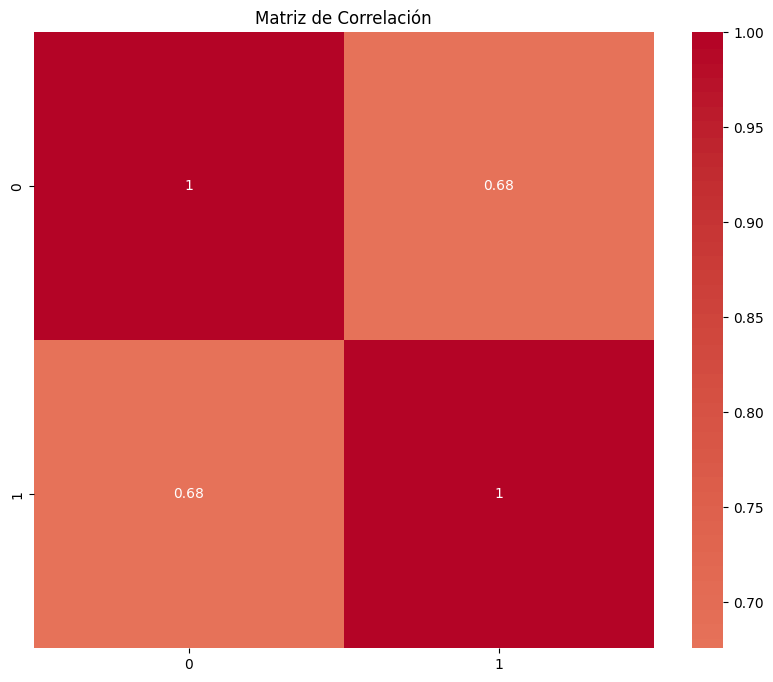

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Matriz de Correlación")
plt.show()

Ejemplo 2: Se usa el dataset de Heart Disease que tiene información sobre pacientes con enfermedades del corazón. Esta base de datos contiene 76 atributos, pero todos los experimentos publicados se refieren al uso de un subconjunto de 14 de ellos. En particular, la base de datos de Cleveland es la única que ha sido utilizada por investigadores en Aprendizaje Automático hasta la fecha. El campo "goal" se refiere a la presencia de enfermedad cardíaca en el paciente. Tiene valores enteros que van de 0 (ausencia) a 4.

1. age: Edad del paciente.
2. sex: Género del paciente (0 = mujer, 1 = hombre).
3. cp: Tipo de dolor en el pecho reportado por el paciente (Valor entre 1 y 4).
*   1: Angina típica
*   2: Angina atípica
*   3: Dolor no anginoso
*   4: Asintomático
4. trestbps: Presión arterial en reposo del paciente.
5. chol: Nivel de colesterol sérico del paciente.
6. fbs: Nivel de azúcar en sangre en ayunas (1 si es mayor que 120 mg/dl, 0 en caso contrario).
7. restecg: Resultado del electrocardiograma en reposo.
*   0: Normal
*   1: Con anomalías de ST-T
*   2: Mostrando hipertrofia ventricular izquierda probable o definitiva
8. thalach: Frecuencia cardíaca máxima alcanzada.
9. exang: Angina inducida por ejercicio (1 = sí, 0 = no).
10. oldpeak: Depresión del ST inducida por el ejercicio en relación con el descanso.
11. slope: Pendiente del segmento ST de ejercicio máximo.
*   1: Ascendente
*   2: Plano
*   3: Descendente
12. ca: Número de vasos principales coloreados por flourosopía.
thal: Tipo de thalassemia.
*   3: Normal
*   6: Defecto fijo
*   7: Defecto reversible

In [ ]:
# Cargar el conjunto de datos Heart Disease
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
column_names = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach", "exang", "oldpeak",
                "slope", "ca", "thal", "target"]
heart_df = pd.read_csv(url, names=column_names)
heart_df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,2
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,3
301,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0,1


In [ ]:
# 1. Análisis Descriptivo Categórico
categorical_variables = heart_df[["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal", "target"]]
for col in categorical_variables.columns:
    value_counts = categorical_variables[col].value_counts()
    print(f"Conteo de valores para '{col}':\n{value_counts}\n")

Conteo de valores para 'sex':
1.0    206
0.0     97
Name: sex, dtype: int64

Conteo de valores para 'cp':
4.0    144
3.0     86
2.0     50
1.0     23
Name: cp, dtype: int64

Conteo de valores para 'fbs':
0.0    258
1.0     45
Name: fbs, dtype: int64

Conteo de valores para 'restecg':
0.0    151
2.0    148
1.0      4
Name: restecg, dtype: int64

Conteo de valores para 'exang':
0.0    204
1.0     99
Name: exang, dtype: int64

Conteo de valores para 'slope':
1.0    142
2.0    140
3.0     21
Name: slope, dtype: int64

Conteo de valores para 'ca':
0.0    176
1.0     65
2.0     38
3.0     20
?        4
Name: ca, dtype: int64

Conteo de valores para 'thal':
3.0    166
7.0    117
6.0     18
?        2
Name: thal, dtype: int64

Conteo de valores para 'target':
0    164
1     55
2     36
3     35
4     13
Name: target, dtype: int64



In [ ]:
# 2. Covarianza y Correlación (solo para variables numéricas)
numeric_variables = heart_df[["age", "trestbps", "chol", "thalach", "oldpeak"]]
cov_matrix = numeric_variables.cov()  # Matriz de covarianza
correlation_matrix = numeric_variables.corr()  # Matriz de correlación


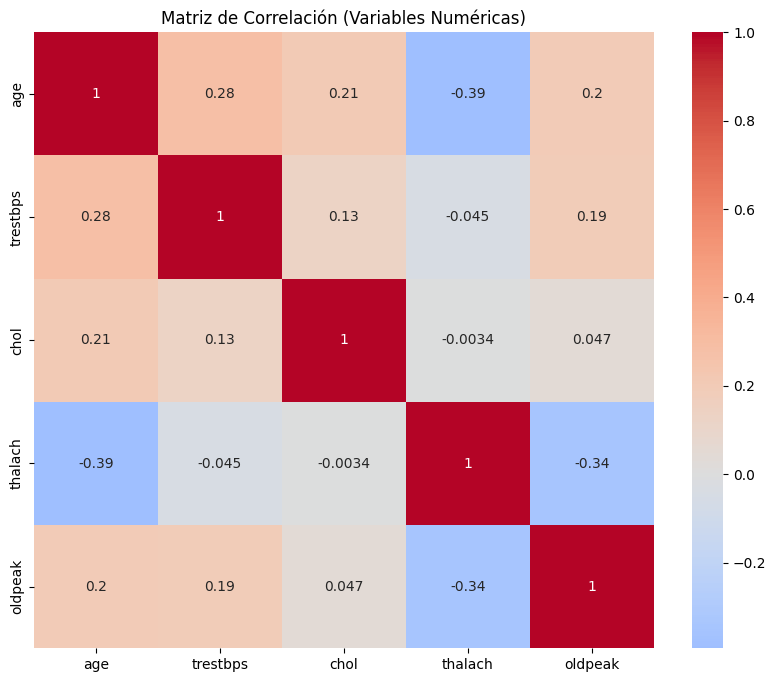

In [ ]:
# Visualización de la matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Matriz de Correlación (Variables Numéricas)")
plt.show()

## 2.2 Pruebas de hipótesis

una prueba de hipótesis es un proceso estadístico utilizado para tomar decisiones sobre afirmaciones o suposiciones acerca de una población o un fenómeno basándose en evidencia empírica. Estas pruebas son fundamentales en el campo de la estadística inferencial y se utilizan para sacar conclusiones sobre una población en función de la información contenida en una muestra.

Los principales componentes del proceso de una prueba de hipótesis son:

*   ***Hipótesis Nula (H0):*** La hipótesis nula es una afirmación que asume que no hay efecto o diferencia real en la población. Por ejemplo, "la media de un tratamiento es igual a la media de otro tratamiento". La hipótesis nula es la hipótesis que se someterá a prueba.

*   ***Hipótesis Alternativa (H1 o Ha):*** La hipótesis alternativa es la afirmación que deseamos probar o respaldar con evidencia. Por ejemplo, "la media de un tratamiento no es igual a la media de otro tratamiento". La hipótesis alternativa puede ser de dos tipos: bilateral (no igualdad) o unilateral (mayor o menor).

*   ***Nivel de Significancia (α):*** El nivel de significancia es la probabilidad máxima que un estadístico de prueba pueda tomar bajo la hipótesis nula antes de rechazarla. Es un umbral predefinido (comúnmente 0.05) que se utiliza para determinar si se rechaza o no la hipótesis nula.

*   ***Estadístico de Prueba:*** El estadístico de prueba es un valor calculado a partir de los datos de la muestra y que se compara con la distribución de probabilidad bajo la hipótesis nula. Ejemplos de estadísticos de prueba incluyen la prueba t, la prueba F y la prueba Z, dependiendo del tipo de prueba y de los datos.

*   ***Valor p:*** El valor p es la probabilidad de obtener un estadístico de prueba tan extremo como el observado, asumiendo que la hipótesis nula es verdadera. Un valor p pequeño sugiere que la evidencia observada es poco probable bajo la hipótesis nula y proporciona una razón para rechazarla.

*   ***Toma de Decisión:*** Si el valor p es menor que el nivel de significancia (α), se rechaza la hipótesis nula y se acepta la hipótesis alternativa. Si el valor p es mayor que α, no se rechaza la hipótesis nula. La decisión debe interpretarse en el contexto del problema y el campo de estudio.

*   ***Conclusión:*** Se concluye si se rechaza o no la hipótesis nula, y se brinda una interpretación de los resultados en términos del problema original.

En resumen, una prueba de hipótesis es un proceso estructurado que ayuda a tomar decisiones basadas en datos. Estas pruebas proporcionan un marco riguroso para evaluar afirmaciones y tomar decisiones informadas sobre una población o fenómeno, en función de la evidencia empírica de una muestra.